In [55]:
import pandas as pd
import numpy as np 
import random
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

In [56]:
data = load_breast_cancer(as_frame=True)
df = data.frame
print(df.head())

x_df = df.iloc[:,:-1]
std_x = StandardScaler().fit_transform(x_df.values)
df_scaled = std_x
df_scaled = pd.DataFrame(std_x, columns=[f'F({i+1})' for i in (range(df_scaled.shape[1]))])
y = np.array(df.iloc[:,-1])

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

In [57]:
print(df_scaled.head())

       F(1)      F(2)      F(3)      F(4)      F(5)      F(6)      F(7)  \
0  1.097064 -2.073335  1.269934  0.984375  1.568466  3.283515  2.652874   
1  1.829821 -0.353632  1.685955  1.908708 -0.826962 -0.487072 -0.023846   
2  1.579888  0.456187  1.566503  1.558884  0.942210  1.052926  1.363478   
3 -0.768909  0.253732 -0.592687 -0.764464  3.283553  3.402909  1.915897   
4  1.750297 -1.151816  1.776573  1.826229  0.280372  0.539340  1.371011   

       F(8)      F(9)     F(10)  ...     F(21)     F(22)     F(23)     F(24)  \
0  2.532475  2.217515  2.255747  ...  1.886690 -1.359293  2.303601  2.001237   
1  0.548144  0.001392 -0.868652  ...  1.805927 -0.369203  1.535126  1.890489   
2  2.037231  0.939685 -0.398008  ...  1.511870 -0.023974  1.347475  1.456285   
3  1.451707  2.867383  4.910919  ... -0.281464  0.133984 -0.249939 -0.550021   
4  1.428493 -0.009560 -0.562450  ...  1.298575 -1.466770  1.338539  1.220724   

      F(25)     F(26)     F(27)     F(28)     F(29)     F(30)  
0  1

In [58]:
def Kmeans_new(df, k, Epochs=100, tol=0.0004):

    data = np.array(df)
    n_row, n_col = data.shape

    epoch = 1
    centroid_diff = 1

    c_ind = random.sample(range(n_row),k)
    centroids = data[c_ind,:]
    
    while(epoch < Epochs and centroid_diff > tol):
        dist = np.zeros((n_row, k))
        for j in range(k):
            dist[:,j] = np.linalg.norm(data - centroids[j], axis=1)

        cluster = np.argmin(dist, axis=1)
        new_centroids = np.zeros((k, n_col))
        
        for j in range(k):
            points_in_cluster = data[cluster == j]
            
            if len(points_in_cluster) > 0:
                new_centroids[j] = np.mean(points_in_cluster, axis=0)
            
        centroid_diff = np.linalg.norm(new_centroids - centroids)
        centroids = new_centroids

        epoch += 1

    return cluster, centroids, epoch

In [59]:
cluster_labels, centroids, iter = Kmeans_new(df_scaled, 2)
print("Cluster Labels:\n", cluster_labels)
print("Centroids:\n", centroids)
print("Number of interations:", iter)

Cluster Labels:
 [0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 1 1 1 1 0 0 1 0 1 0 1 1 1 1 1 0 1 1 0 0 1 1 1 1 0 1 0 0 1 1 0 1 0 1 0 1
 1 0 1 0 0 1 1 0 0 0 1 0 1 0 1 0 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 0 1 1 0 1 1
 1 0 1 1 1 1 0 0 1 1 0 0 1 1 1 1 0 0 0 1 0 0 1 0 1 1 1 0 1 1 0 1 1 1 1 0 1
 1 1 1 1 0 1 1 1 0 1 1 1 1 0 0 1 0 1 1 0 0 1 1 1 0 1 1 1 0 0 1 1 0 0 1 1 1
 1 1 1 1 1 0 1 1 0 0 1 0 0 0 0 1 0 0 0 1 1 1 1 1 1 0 1 0 0 0 0 1 1 0 0 1 1
 1 0 1 1 1 1 1 0 0 1 1 0 1 1 0 0 1 0 1 1 0 1 0 1 1 0 1 1 0 1 0 0 0 1 0 0 0
 0 0 1 0 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1
 1 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 0 1 0 1 1 1 1 0 0 0 1 1
 1 1 0 1 0 1 0 1 1 1 0 1 1 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0 0
 0 1 0 0 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1
 1 0 1 1 1 1 1 1 1 1 0 1 1 1 0 1 1 1 1 1 1 1 1 0 1 0 0 1 1 1 1 1 1 1 0 1 1
 1 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1
 1 1 1 1

Cluster Counts: [194, 375]


Text(0.5, 1.0, 'Cluster Counts')

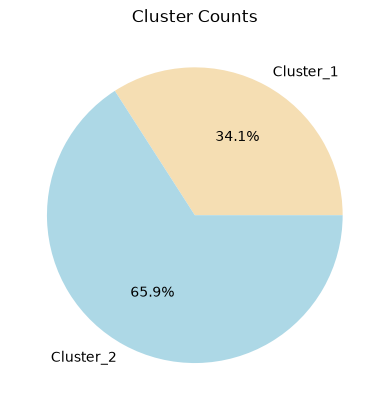

In [60]:
count = [0,0]
for i in range(len(cluster_labels)):
    if cluster_labels[i] == 0:
        count[0] += 1
    else:
        count[1] += 1

print("Cluster Counts:", count)

plt.pie(count,labels = ["Cluster_1","Cluster_2"],autopct="%1.1f%%",colors=["wheat","lightblue"])
plt.title('Cluster Counts')

In [61]:
def Kmeans_plus(df, k, Epochs=100, tol=0.0004):

    data = np.array(df)
    n_row, n_col = data.shape

    epoch = 1
    centroid_diff = 1
    
    diff = np.zeros(n_row)
    c_ind = random.sample(range(n_row),1)
    
    for i in range(n_row):
        diff[i] = np.linalg.norm(data[i,:] - data[c_ind,:])

    argmin_indices = np.argpartition(diff, k)[:k]
    centroids = data[argmin_indices,:]
    
    while(epoch < Epochs and centroid_diff > tol):
        dist = np.zeros((n_row, k))
        for j in range(k):
            dist[:,j] = np.linalg.norm(data - centroids[j], axis=1)

        cluster = np.argmin(dist, axis=1)
        new_centroids = np.zeros((k, n_col))
        
        for j in range(k):
            points_in_cluster = data[cluster == j]
            
            if len(points_in_cluster) > 0:
                new_centroids[j] = np.mean(points_in_cluster)

        centroid_diff = np.linalg.norm(new_centroids - centroids)
        centroids = new_centroids

        epoch += 1

    return cluster, centroids, epoch

In [62]:
cluster_labels1, centroids1, iter1 = Kmeans_plus(df_scaled, 2)
print("Cluster Labels:\n", cluster_labels1)
print("Centroids:\n", centroids1)
print("Number of iterations:", iter1)

Cluster Labels:
 [0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0 1 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 1 1 1 1 1 0 1 1 0 1 0 1 1 1 1 1 0 1 1 0 0 1 1 1 1 0 1 0 0 1 1 0 1 0 0 0 1
 1 1 1 0 0 1 1 0 0 0 1 0 1 0 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 0 1 1 0 1 1
 1 0 1 1 1 1 0 0 1 1 0 0 1 1 1 1 1 0 0 1 1 1 1 0 1 1 1 0 1 1 1 1 1 1 1 0 1
 1 1 1 0 0 1 1 1 0 1 1 1 1 0 0 1 0 1 1 1 0 1 1 1 0 1 1 1 0 0 1 1 0 0 1 1 1
 1 1 1 1 1 0 1 1 0 0 1 0 1 0 1 1 1 0 0 1 1 1 1 1 1 0 1 0 0 0 0 1 1 0 0 1 1
 1 0 1 1 1 1 1 0 0 1 1 0 1 1 0 0 1 0 1 1 0 1 0 1 1 1 1 1 0 1 0 1 0 1 0 0 0
 0 0 1 0 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 0 0 1 1 1 1 0 1 0 1 1 1 1 1
 1 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 0 0 1 1 1
 1 1 0 1 0 1 0 1 1 1 0 1 1 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0 0
 0 1 0 0 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1
 1 0 1 1 1 1 1 1 1 1 0 1 1 1 0 1 1 1 1 1 1 1 1 0 1 0 0 1 1 1 1 1 1 1 0 1 1
 1 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 0 1 1 0 0 1 1 1 1 1 1 1 1 1 0 1
 1 1 1 1

Cluster Counts: [180, 389]


Text(0.5, 1.0, 'Cluster Counts')

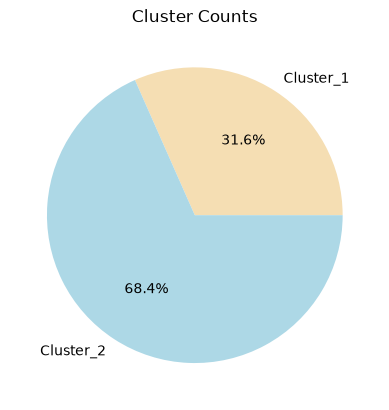

In [63]:
count1 = [0,0]
for i in range(len(cluster_labels1)):
    if cluster_labels1[i] == 0:
        count1[0] += 1
    else:
        count1[1] += 1

print("Cluster Counts:", count1)

plt.pie(count1,labels = ["Cluster_1","Cluster_2"],autopct="%1.1f%%",colors=["wheat","lightblue"])
plt.title('Cluster Counts')